In [25]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

In [37]:
# Choose either one of the below documents:

documents = [
    "The economy is working better than ever", # economy
    "The president is speaking on the economy", # economy
    "The sports team won the championship", # sports
    "The new movie was a hit at the box office", # movie
    "The local team lost the game last night", # sports
    "The government is working on new policies", # economy
    "The film received great reviews from critics", # movie
    "The match was intense and thrilling", # sports
    "The administration is focusing on economic growth", # economy
    "The actor won an award for his performance", # movie
]

# The following works too
# documents = [
#     # economy
#     "The government introduced a new policy aimed at improving the economy by creating more jobs.",
#     "Market analysts believe that better fiscal strategies will enhance economic growth and employment rates.",
#     "To improve the job market, the government is focusing on policies that stimulate economic development.",
#     "Economic experts suggest that better governance and policy reforms are essential for a thriving market.",
#     "The government's commitment to job creation reflects its strategy to improve the overall economy and market stability.",

#     # sports
#     "The sports team trained rigorously to prepare for the championship match.",
#     "Despite their best efforts, the team lost the game against the reigning champions.",
#     "After a series of intense matches, they finally won and were crowned champions.",
#     "The underdog team surprised everyone when they won the crucial game.",
#     "Even though they lost the match, the team's performance was commendable in the sports community.",

#      # movie
#     "The action-packed movie became a box office hit, earning rave reviews from critics and audiences alike.",
#     "The lead actor delivered a stellar performance in the action film, which was nominated for several Oscars.",
#     "Despite mixed reviews, the movie's thrilling action sequences propelled it to box office success.",
#     "The actor's portrayal in the movie garnered critical acclaim, leading to an Oscar win and a significant box office hit.",
#     "The action movie received outstanding reviews and became a surprise hit during the Oscars season.",
# ]


In [38]:
#  Convert Text to TF-IDF Matrix
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(documents)

The result of lsa_model.fit_transform(X) yields the document-topic matrix, where each row
represents a document's representation in the topic space. This matrix can be used to:

- Cluster documents: Group similar documents based on their topic representations.
- Visualize topics: Use dimensionality reduction techniques like t-SNE or UMAP to visualize document distributions.
- Build classifiers: Use the topic representations as features for supervised learning tasks

In [64]:
# Apply LSA using Truncated SVD
n_topics = 2  # Number of topics
lsa_model = TruncatedSVD(n_components=n_topics, random_state=42)
lsa_topic_matrix = lsa_model.fit_transform(X)


In [65]:
# Display Top Terms per Topic
terms = vectorizer.get_feature_names_out()
for i, comp in enumerate(lsa_model.components_):
    terms_in_topic = zip(terms, comp)
    sorted_terms = sorted(terms_in_topic, key=lambda x: x[1], reverse=True)[:5]
    print(f"Topic {i+1}:")
    for term, weight in sorted_terms:
        print(f"  {term} ({weight:.4f})")
    print()


Topic 1:
  economy (0.5118)
  working (0.5107)
  better (0.3603)
  new (0.2834)
  president (0.2418)

Topic 2:
  won (0.4941)
  team (0.4504)
  championship (0.3381)
  sports (0.3381)
  performance (0.2432)



These results suggest that Topic *1* is related to economic and governmental discussions, while Topic 2 pertains to sports events.

**Analyse**

In [72]:
print(X.shape)
print("#####################")
print(X)

(10, 35)
#####################
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 40 stored elements and shape (10, 35)>
  Coords	Values
  (0, 8)	0.5436239518925301
  (0, 34)	0.5436239518925301
  (0, 3)	0.6394888567109641
  (1, 8)	0.5151921890284284
  (1, 26)	0.6060433187339399
  (1, 29)	0.6060433187339399
  (2, 30)	0.5387481691380603
  (2, 31)	0.4579851637885095
  (2, 33)	0.4579851637885095
  (2, 5)	0.5387481691380603
  (3, 21)	0.3911762483232489
  (3, 20)	0.4601578921271882
  (3, 15)	0.4601578921271882
  (3, 4)	0.4601578921271882
  (3, 23)	0.4601578921271882
  (4, 31)	0.3911762483232489
  (4, 17)	0.4601578921271882
  (4, 18)	0.4601578921271882
  (4, 11)	0.4601578921271882
  (4, 22)	0.4601578921271882
  (5, 34)	0.4579851637885095
  (5, 21)	0.4579851637885095
  (5, 12)	0.5387481691380603
  (5, 25)	0.5387481691380603
  (6, 9)	0.4472135954999579
  (6, 27)	0.4472135954999579
  (6, 13)	0.4472135954999579
  (6, 28)	0.4472135954999579
  (6, 6)	0.4472135954999579
  (7, 19)	0.577350

In [73]:
# Assuming 'lsa_topic_matrix' is the result of fit_transform
# This matrix represents each document in the reduced topic space.
# Shape Explanation: If you have n_documents and choose n_topics, the shape will be (n_documents, n_topics).
print("Document-Topic Matrix (U):")
print(lsa_topic_matrix)
print("Shape:", lsa_topic_matrix.shape)
print("*****************")

Document-Topic Matrix (U):
[[ 7.86252767e-01  5.70963027e-18]
 [ 5.56765807e-01 -2.74319810e-15]
 [-8.21487981e-16  7.96818472e-01]
 [ 2.82066648e-01  2.15037630e-15]
 [-4.24791240e-16  5.29027188e-01]
 [ 6.22709277e-01  3.52854384e-15]
 [-5.22115085e-17 -2.35971390e-16]
 [-5.56715287e-16  7.05356138e-16]
 [ 7.44521846e-16  2.16066650e-15]
 [-5.05614073e-16  5.95860647e-01]]
Shape: (10, 2)
*****************


In [75]:
# The singular_values_ attribute provides the singular values corresponding to each selected component.
# These values can be used to compute the actual explained variance for each component.
print("Singular Values (Σ):")
print(lsa_model.singular_values_)

# Shape Explanation: This will be a 1D array with length equal to n_topics.
print("Shape:", lsa_model.singular_values_.shape)

Singular Values (Σ):
[1.18131707 1.12687149]
Shape: (2,)


In [76]:
# The components_ attribute provides the term-topic matrix, where each row corresponds to a
# topic, and each column corresponds to a term's weight in that topic. This matrix is useful for:

# Identifying top terms: As previously demonstrated, extracting the most significant terms per topic.
# Understanding topic composition: Analyzing how terms contribute to each topic

print("Term-Topic Matrix (V^T):")
print(lsa_model.components_)
print("Shape:", lsa_model.components_.shape)


Term-Topic Matrix (V^T):
[[-1.69889077e-16  4.38191693e-16 -2.04599013e-16  3.60298298e-01
   9.30091458e-02 -3.65318103e-16 -1.77936837e-17  3.51446497e-16
   5.11832394e-01 -2.90784083e-17  3.49702751e-16 -1.44801319e-16
   2.40402060e-01 -2.56063836e-17  3.49702751e-16  9.30091458e-02
  -3.21636561e-16 -1.44801319e-16 -1.44801319e-16 -3.21636561e-16
   9.30091458e-02  2.83429986e-01 -1.48270765e-16  9.30091458e-02
  -1.75103558e-16  2.40402060e-01  2.41792745e-01 -2.21350034e-17
  -2.21350034e-17  2.41792745e-01 -3.93073679e-16 -4.00507110e-16
  -3.20986040e-16 -5.01063136e-16  5.10650185e-01]
 [ 2.43203325e-01  1.14371853e-15  2.43203325e-01 -1.10428154e-16
   7.78258844e-16  3.38062048e-01 -1.08939847e-16  1.07011196e-15
  -1.43125505e-15 -1.04483863e-16  1.05375126e-15  1.91706168e-01
   1.76143834e-15 -1.07739542e-16  1.05375126e-15  7.35336730e-16
   4.02828468e-16  1.91706168e-01  1.91706168e-01  4.02828468e-16
   7.35336730e-16  1.98871891e-15  1.91706168e-01  7.33602007e-16


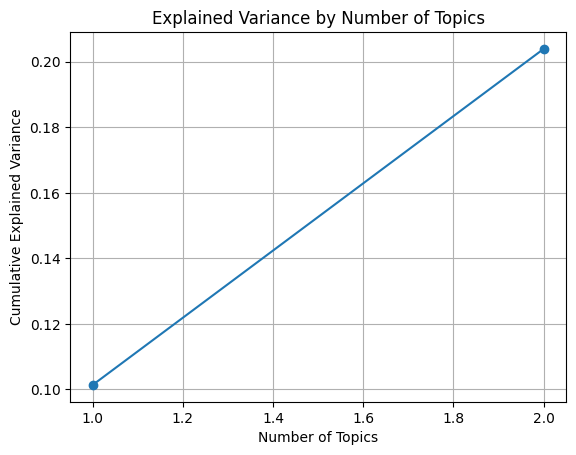

In [69]:
# Cumulative Explained Variance
# To determine the optimal number of topics, you can plot the cumulative explained variance to see
#  how much total variance is captured as you increase the number of components.

import matplotlib.pyplot as plt
import numpy as np

cumulative_variance = np.cumsum(lsa_model.explained_variance_ratio_)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.xlabel('Number of Topics')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by Number of Topics')
plt.grid(True)
plt.show()


In [77]:
# Reconstructing the Original Matrix (Approximation)
# You can approximate the original TF-IDF matrix by multiplying the Document-Topic Matrix with the Term-Topic Matrix:
approximation = np.dot(lsa_topic_matrix, lsa_model.components_)
print("Approximated TF-IDF Matrix:")
print(approximation)

# Shape Explanation: The shape will be (n_documents, n_features), matching the original TF-IDF matrix.
print("Shape:", approximation.shape)


Approximated TF-IDF Matrix:
[[-1.32187156e-16  3.44529431e-16 -1.59477939e-16  2.83285534e-01
   7.31286982e-02 -2.85302160e-16 -1.39903330e-17  2.76325780e-16
   4.02429636e-01 -2.28629789e-17  2.74954756e-16 -1.12755866e-16
   1.89016785e-01 -2.01330900e-17  2.74954756e-16  7.31286982e-02
  -2.52887636e-16 -1.12755866e-16 -1.12755866e-16 -2.52887636e-16
   7.31286982e-02  2.22847610e-01 -1.15483728e-16  7.31286982e-02
  -1.36287056e-16  1.89016785e-01  1.90110215e-01 -1.74037076e-17
  -1.74037076e-17  1.90110215e-01 -3.07125058e-16 -3.12328483e-16
  -2.52376162e-16 -3.91140985e-16  4.01500120e-01]
 [-7.61743328e-16  2.43970151e-16 -7.81068633e-16  2.00601773e-01
   5.17843121e-02 -1.13076780e-15 -9.90691466e-18  1.95673392e-16
   2.84970776e-01 -1.61898634e-17  1.94702535e-16 -6.06508417e-16
   1.33847647e-01 -1.42567588e-17  1.94702535e-16  5.17843121e-02
  -1.79076240e-16 -6.06508417e-16 -6.06508417e-16 -1.79076240e-16
   5.17843121e-02  1.57804125e-01 -6.08440087e-16  5.17843121e-